In [ ]:
# Name: Nimotallahi Abiodun Durojaiye
# WTF ID: WTF/2025/5891
# MAIL: nimotallahi02@outlook.com
# Data Cleaning and Prediiction Analysis (HR File)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder


In [ ]:
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [ ]:
!ls "/content/drive/My Drive/Colab Notebooks/hiring (1).csv"


'/content/drive/My Drive/Colab Notebooks/hiring (1).csv'


In [ ]:
file_path = "/content/drive/My Drive/Colab Notebooks/hiring (1).csv"

# Load dataset
df = pd.read_csv(file_path)

# Display first few rows
print(df.head())


  experience  test_score(out of 10)  interview_score(out of 10)  salary($)
0        NaN                    8.0                           9      50000
1        NaN                    8.0                           6      45000
2       five                    6.0                           7      60000
3        two                   10.0                          10      65000
4      seven                    9.0                           6      70000


In [ ]:
import numpy as np

# Fill missing test scores with the mean
df['test_score(out of 10)'].fillna(df['test_score(out of 10)'].mean(), inplace=True)

# Convert experience column to numeric values
def convert_to_num(x):
    try:
        return int(x)
    except:
        word_to_num = {
            'zero':0, 'one':1, 'two':2, 'three':3, 'four':4, 'five':5,
            'six':6, 'seven':7, 'eight':8, 'nine':9, 'ten':10,
            'eleven':11, 'twelve':12
        }
        return word_to_num.get(str(x).lower(), np.nan)

df['experience'] = df['experience'].apply(convert_to_num)

# Check the cleaned dataset
print(df)


   experience  test_score(out of 10)  interview_score(out of 10)  salary($)
0         NaN               8.000000                           9      50000
1         NaN               8.000000                           6      45000
2         5.0               6.000000                           7      60000
3         2.0              10.000000                          10      65000
4         7.0               9.000000                           6      70000
5         3.0               7.000000                          10      62000
6        10.0               7.857143                           7      72000
7        11.0               7.000000                           8      80000


/tmp/ipython-input-856242225.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['test_score(out of 10)'].fillna(df['test_score(out of 10)'].mean(), inplace=True)


In [ ]:
# Fill missing experience values with the mean of the column
df['experience'].fillna(df['experience'].mean(), inplace=True)

# Double-check that no NaNs remain
print(df.isnull().sum())
print(df)



experience                    0
test_score(out of 10)         0
interview_score(out of 10)    0
salary($)                     0
dtype: int64
   experience  test_score(out of 10)  interview_score(out of 10)  salary($)
0    6.333333               8.000000                           9      50000
1    6.333333               8.000000                           6      45000
2    5.000000               6.000000                           7      60000
3    2.000000              10.000000                          10      65000
4    7.000000               9.000000                           6      70000
5    3.000000               7.000000                          10      62000
6   10.000000               7.857143                           7      72000
7   11.000000               7.000000                           8      80000


/tmp/ipython-input-1432911066.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['experience'].fillna(df['experience'].mean(), inplace=True)


In [ ]:
from sklearn.linear_model import LinearRegression

# Features and target
X = df[['experience','test_score(out of 10)','interview_score(out of 10)']]
y = df['salary($)']

# Train model
model = LinearRegression()
model.fit(X, y)

# Show coefficients and intercept
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)


Coefficients: [2633.0537639  1203.95910777 2787.82004231]
Intercept: 14910.231291544944


The coefficients show how much each factor contributes to salary:

Experience adds about 2633 per year.

Test score adds about 1204 per point.

Interview score adds about 2788 per point.

Intercept is the baseline salary (≈ 14,910).

In [ ]:
import numpy as np

# Candidate 1: 2 yr experience, 9 test score, 6 interview score
candidate1 = np.array([2, 9, 6]).reshape(1, -1)

# Candidate 2: 12 yr experience, 10 test score, 10 interview score
candidate2 = np.array([12, 10, 10]).reshape(1, -1)

print("Predicted salary for candidate 1:", model.predict(candidate1)[0])
print("Predicted salary for candidate 2:", model.predict(candidate2)[0])


Predicted salary for candidate 1: 47738.891043133306
Predicted salary for candidate 2: 86424.66795913098


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


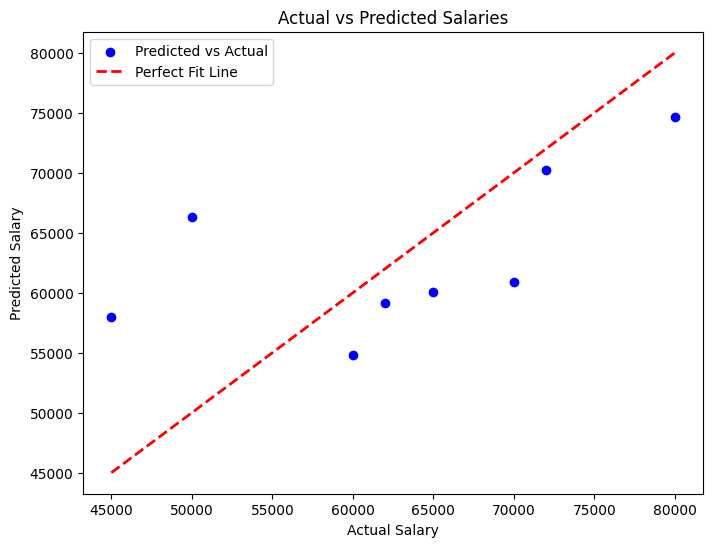

In [ ]:
import matplotlib.pyplot as plt

# Predict salaries for all rows in the dataset
y_pred = model.predict(X)

# Plot actual vs predicted
plt.figure(figsize=(8,6))
plt.scatter(y, y_pred, color='blue', label='Predicted vs Actual')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect Fit Line')

plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salaries")
plt.legend()
plt.show()

